### Todos os imports necessários juntos da instalação das bibliotecas caso seja necessário

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

sns.set(style="whitegrid")

### Gerar dados sintéticos

In [2]:
def gerar_base_sintetica(n=50000, seed=42):
    rng = np.random.default_rng(seed)
    
    culturas = ["soja", "milho", "cafe"]
    label = rng.choice(culturas, size=n, p=[0.34, 0.33, 0.33])

    # Variáveis agronômicas sintéticas
    N = rng.normal(60, 15, size=n).clip(10, 120)
    P = rng.normal(40, 10, size=n).clip(5, 80)
    K = rng.normal(50, 12, size=n).clip(10, 100)

    temperature = rng.normal(26, 4, size=n).clip(10, 40)
    humidity = rng.normal(45, 15, size=n).clip(5, 95)
    pH = rng.normal(6.4, 0.5, size=n).clip(4.5, 8.5)
    rainfall = rng.gamma(2, 2, size=n).clip(0, 20)

    df = pd.DataFrame({
        "N": N,
        "P": P,
        "K": K,
        "temperature": temperature,
        "humidity": humidity,
        "pH": pH,
        "rainfall": rainfall,
        "label": label
    })
    return df

df = gerar_base_sintetica()
df.head()

,N,P,K,temperature,humidity,pH,rainfall,label
0,60.720660,53.748049,39.255059,25.204105,28.561570,5.953810,3.162930,cafe
1,47.199468,31.996033,14.856358,25.498521,41.651437,6.501986,2.136982,milho
2,66.887415,42.910995,28.728604,18.104889,50.107795,6.129332,1.434284,cafe
3,62.555119,37.626281,29.705400,26.461704,42.970098,6.742759,10.028082,cafe
4,56.721029,29.743433,69.565660,20.337375,69.842730,5.885175,2.250233,soja


### Análise exploratória básica

In [3]:
print(df.shape)
print(df.info())
df.describe().T

(50000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            50000 non-null  float64
 1   P            50000 non-null  float64
 2   K            50000 non-null  float64
 3   temperature  50000 non-null  float64
 4   humidity     50000 non-null  float64
 5   pH           50000 non-null  float64
 6   rainfall     50000 non-null  float64
 7   label        50000 non-null  object 
dtypes: float64(7), object(1)
memory usage: 3.1+ MB
None


,count,mean,std,min,25%,50%,75%,max
N,50000.0,59.873857,15.062112,10.000000,49.748701,59.792242,70.031969,120.000000
P,50000.0,39.982645,10.050097,5.000000,33.195009,39.936573,46.735547,80.000000
K,50000.0,50.083943,11.968819,10.000000,41.995106,50.122980,58.183243,100.000000
temperature,50000.0,26.013256,3.980912,10.000000,23.334174,26.039156,28.698002,40.000000
humidity,50000.0,45.000885,14.924825,5.000000,34.837435,44.894927,55.080939,95.000000
pH,50000.0,6.400311,0.499263,4.500000,6.066541,6.400232,6.736379,8.446611
rainfall,50000.0,3.986724,2.813719,0.014402,1.910878,3.347035,5.397353,20.000000


### Distribuição das Culturas

In [4]:
df["label"].value_counts()

label
soja     16955
cafe     16595
milho    16450
Name: count, dtype: int64

### EDA - 5 gráficos

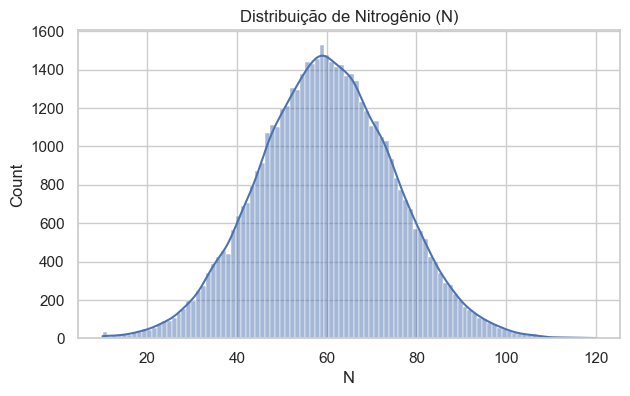

In [5]:
# Distribuição de Nitrogênio
plt.figure(figsize=(7,4))
sns.histplot(df["N"], kde=True)
plt.title("Distribuição de Nitrogênio (N)")
plt.show()

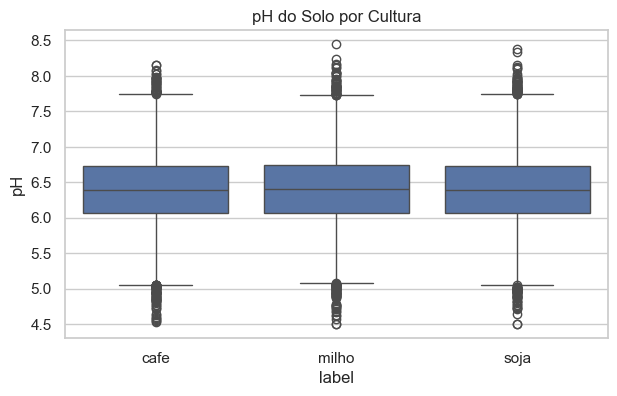

In [7]:
# pH por tipo de cultura
plt.figure(figsize=(7,4))
sns.boxplot(x="label", y="pH", data=df)
plt.title("pH do Solo por Cultura")
plt.show()

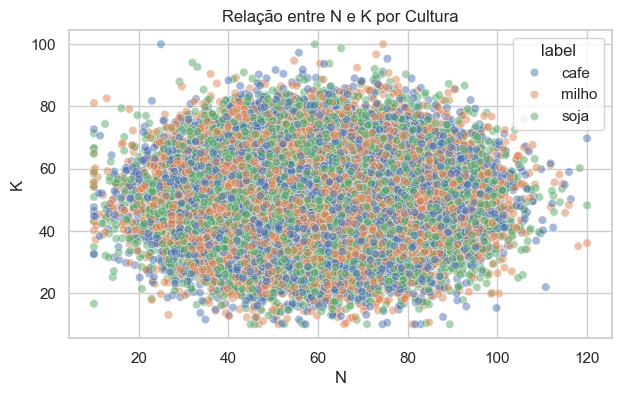

In [8]:
# Dispersão N x K colorido por cultura
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x="N", y="K", hue="label", alpha=0.5)
plt.title("Relação entre N e K por Cultura")
plt.show()

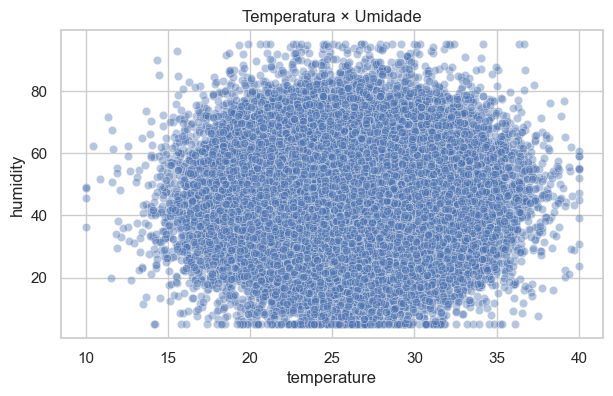

In [10]:
# Relação entre temperatura e umidade: 
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x="temperature", y="humidity", alpha=0.4)
plt.title("Temperatura × Umidade")
plt.show()

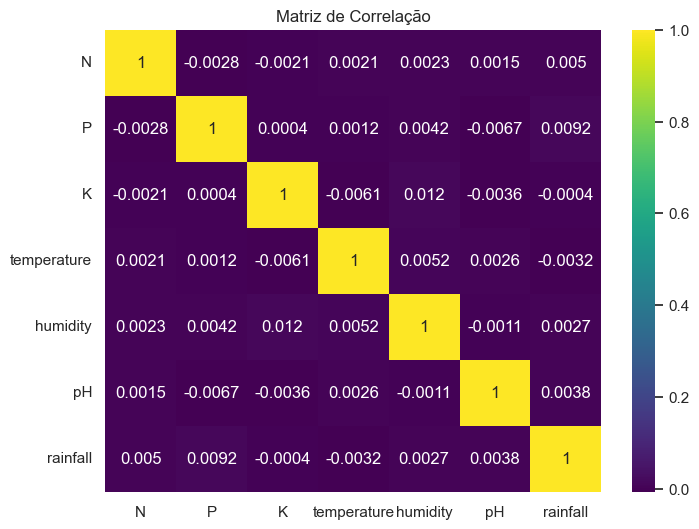

In [11]:
# Correlação
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="viridis")
plt.title("Matriz de Correlação")
plt.show()

### Perfil ideal de Solo/Clima


In [13]:
def perfil_ideal(df):
    perfis = {}

    # colunas numéricas aplicáveis
    cols = ["N", "P", "K", "pH", "temperature", "humidity", "rainfall"]

    for cultura in df["label"].unique():
        subset = df[df["label"] == cultura]

        # usamos um score simples baseado nos principais nutrientes e clima
        score = (subset["N"] + subset["P"] + subset["K"]) + (subset["temperature"] * 0.3) + (subset["humidity"] * 0.2)
        threshold = score.quantile(0.90)

        elite = subset[score >= threshold]

        perfis[cultura] = elite[cols].median()

    return pd.DataFrame(perfis)

perfil_df = perfil_ideal(df)
perfil_df

,cafe,milho,soja
N,77.795647,77.500641,77.605802
P,48.276404,48.275999,47.990992
K,61.452591,61.240766,61.255543
pH,6.381349,6.382993,6.383920
temperature,26.579301,26.471274,26.222397
humidity,48.407980,49.596413,47.940441
rainfall,3.346697,3.355627,3.393547


### Preparação para Machine learning

In [15]:
X = df[["N","P","K","temperature","humidity","pH","rainfall"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Treinamento dos 5 modelos

In [16]:
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC()
}

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    resultados.append([nome, acc])

### Resultado comparativo

In [17]:
df_resultados = pd.DataFrame(resultados, columns=["Modelo","Acurácia"])
df_resultados

,Modelo,Acurácia
0,LogisticRegression,0.33304
1,RandomForest,0.32280
2,GradientBoosting,0.33312
3,KNN,0.33392
4,SVC,0.33448


### Classificação detalhada do melhor modelo

In [18]:
melhor = df_resultados.sort_values(by="Acurácia", ascending=False).iloc[0,0]
print("Melhor modelo:", melhor)

modelo_escolhido = modelos[melhor]
pred = modelo_escolhido.predict(X_test)

print(classification_report(y_test, pred))

Melhor modelo: SVC
              precision    recall  f1-score   support

        cafe       0.33      0.18      0.24      4149
       milho       0.33      0.07      0.11      4112
        soja       0.34      0.74      0.46      4239

    accuracy                           0.33     12500
   macro avg       0.33      0.33      0.27     12500
weighted avg       0.33      0.33      0.27     12500

